In [58]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import requests
from io import BytesIO
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import os

sys.path.append('..')

In [3]:
from wc26_data import get_wc26_data, get_country_rankings, get_ids

/Users/chancetokubo/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [6]:
matches = get_ids("/Users/chancetokubo/bad.sports.metrics/matches.txt")

In [7]:
data = get_wc26_data(matches=matches)

Approximate time of data pulling completion: 120 seconds.
Dataframe Complete


In [10]:
data.tail()

,Date,Group,Stage,TeamID,TeamName,TeamAbbr,Formation,IdMatch,GameNum,StatsId,...,SubstitutionsIn,SubstitutionsOut,TakeOnsCompleted,Threat,ThrowIns,TimePlayed,TopSpeed,TotalDistance,XG,YellowCards
35,2026-06-16T22:00:00Z,Group I,First Stage,43961,Norway,NOR,4-1-2-3,400021488,18,151655,...,5.0,5.0,9.0,60.0,22.0,103.215600,36.520691,116256.851562,2.410916,0.0
36,2026-06-17T01:00:00Z,Group J,First Stage,43922,Argentina,ARG,4-3-3,400021496,19,151662,...,5.0,5.0,4.0,39.0,12.0,99.797100,33.663864,108386.703125,1.584155,0.0
37,2026-06-17T01:00:00Z,Group J,First Stage,43843,Algeria,ALG,4-3-3,400021496,19,151662,...,5.0,5.0,12.0,61.0,19.0,99.797100,33.038010,109318.710938,0.410713,0.0
38,2026-06-17T04:00:00Z,Group J,First Stage,43934,Austria,AUT,4-2-3-1,400021498,20,151661,...,5.0,5.0,4.0,64.0,21.0,106.828333,34.069870,120369.601562,1.931259,1.0
39,2026-06-17T04:00:00Z,Group J,First Stage,43820,Jordan,JOR,3-4-3,400021498,20,151661,...,5.0,5.0,10.0,36.0,19.0,106.828333,34.535961,119221.742188,0.531269,0.0


In [12]:
condensed = data[['TeamName', 'TeamAbbr', 'AvgSpeed', 'PassesCompleted', 'Passes']]
condensed['Pass%'] = condensed['PassesCompleted']/condensed['Passes']

/var/folders/vl/tq28lccn1d19hq22zfhh94lc0000gn/T/ipykernel_51696/660349695.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  condensed['Pass%'] = condensed['PassesCompleted']/condensed['Passes']


In [29]:
condensed.head()

,TeamName,TeamAbbr,AvgSpeed,PassesCompleted,Passes,Pass%
0,Mexico,MEX,5.830074,495.0,547.0,0.904936
1,South Africa,RSA,5.544981,290.0,351.0,0.826211
2,Korea Republic,KOR,6.126048,483.0,542.0,0.891144
3,Czechia,CZE,6.447493,241.0,327.0,0.737003
4,Canada,CAN,6.071703,316.0,412.0,0.766990


In [52]:
def get_flag(team_code):
    url = f"https://api.fifa.com/api/v3/picture/flags-sq-2/{team_code}"
    headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Referer": "https://www.fifa.com/",
    "Origin": "https://www.fifa.com"}
    
    response = requests.get(url, headers=headers)   
    img = Image.open(BytesIO(response.content))
    return img

In [60]:
os.makedirs('flags', exist_ok=True)
def download_flag(team_code):
    url = f"https://api.fifa.com/api/v3/picture/flags-sq-1/{team_code}"
    headers = {
        "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
        "Referer": "https://www.fifa.com/",
        "Origin": "https://www.fifa.com"
    }
    response = requests.get(url, headers=headers)
    with open(f'flags/{team_code}.png', 'wb') as f:
        f.write(response.content)

for code in condensed['TeamAbbr']:
    download_flag(code)

In [61]:
def get_flag(team_code):
    return Image.open(f'flags/{team_code}.png')

In [63]:
get_flag('RSA')

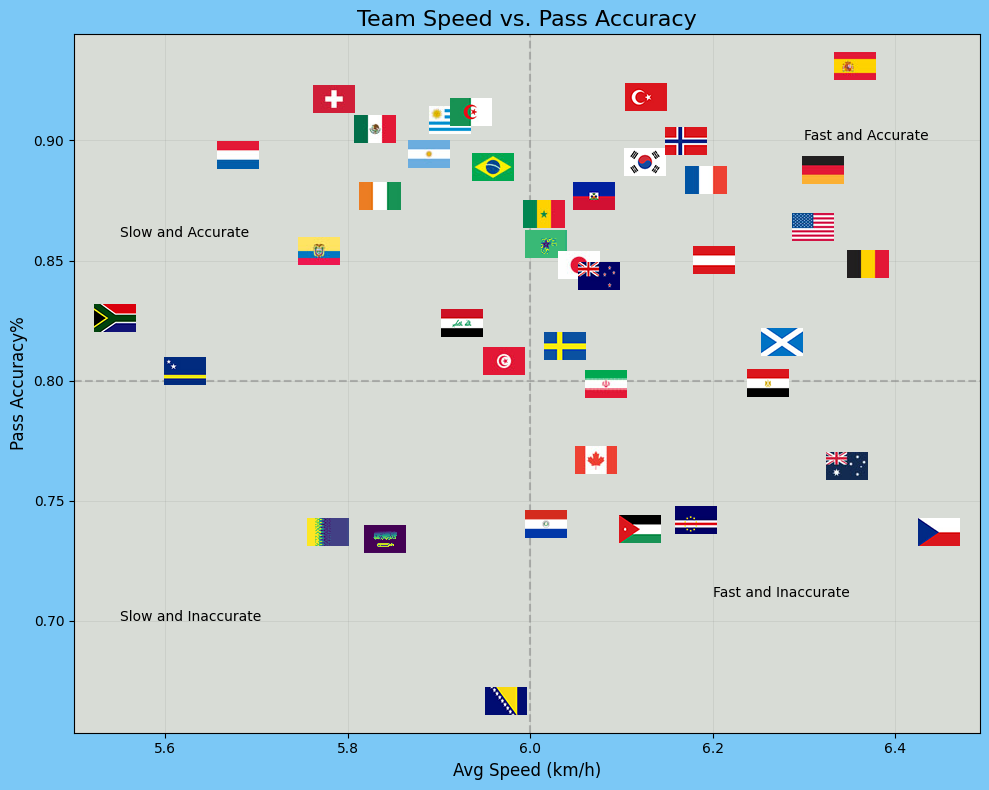

In [126]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('xkcd:lightblue')

ax.scatter('AvgSpeed', 'Pass%', data=condensed)

ax.axvline(6.0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5)

for _, row in condensed.iterrows():
    img = get_flag(row['TeamAbbr'])
    im = OffsetImage(img, zoom=0.72)
    ab = AnnotationBbox(im, (row['AvgSpeed'], row['Pass%']), frameon=False)
    ax.add_artist(ab)
    
ax.set_xlabel('Avg Speed (km/h)', size=12)
ax.set_ylabel('Pass Accuracy%', size=12)
ax.set_title('Team Speed vs. Pass Accuracy', size=16)
ax.set_facecolor('xkcd:light grey')
ax.grid(True, color='grey', linestyle='-', linewidth=0.5, alpha=0.2)

ax.text(5.55,0.86, "Slow and Accurate")
ax.text(6.3,0.9, "Fast and Accurate")
ax.text(6.2,0.71, "Fast and Inaccurate")
ax.text(5.55,0.7, "Slow and Inaccurate")

plt.savefig('speed_vs_pass_accuracy.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.tight_layout()
plt.show()